Найоптимальніше значення K: 20 (MSE: 0.0043, R2: 0.9349)


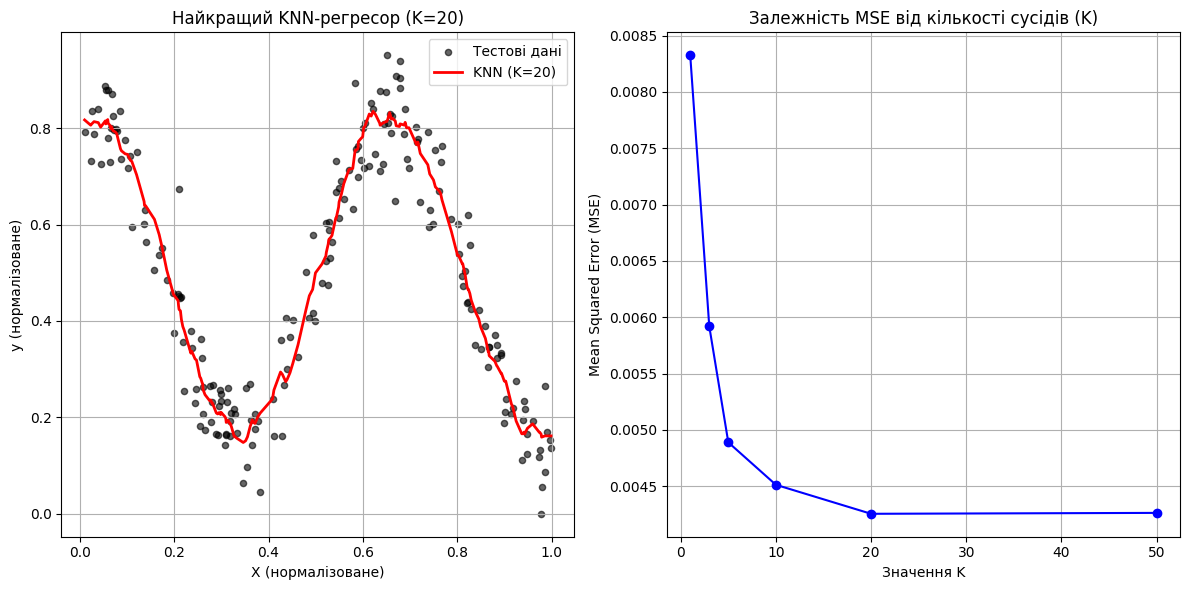

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Згенерувати випадковий набір даних в діапазоні 1000 значень
np.random.seed(42)
X = np.linspace(-5, 5, 1000).reshape(-1, 1) # 1000 значень ознаки
# Генеруємо цільову змінну y на основі синусоїди з додаванням випадкового шуму
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# 2. Нормалізувати значення
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# 3. Розділити існуючі записи на навчальну і тестові вибірки (наприклад, 80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# 4. Навчити KNN-регресор з різними значеннями K
k_values = [1, 3, 5, 10, 20, 50]
results = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    # Розрахунок похибки для оцінки якості
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[k] = {'model': knn, 'mse': mse, 'r2': r2, 'y_pred': y_pred}

# 5. Вибрати величину K для найкращих показників якості регресії у тестовій вибірці
# Найкращим буде те K, у якого мінімальне MSE або максимальне R2
best_k = min(k_values, key=lambda k: results[k]['mse'])
print(f"Найоптимальніше значення K: {best_k} (MSE: {results[best_k]['mse']:.4f}, R2: {results[best_k]['r2']:.4f})")

# 6. Здійснити візуалізації отриманих рішень
plt.figure(figsize=(12, 6))

# Графік 1: Порівняння реальних даних та прогнозу для найкращого K
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='black', label='Тестові дані', alpha=0.6, s=20)
# Відсортуємо для красивого лінійного графіку моделі
sorted_idx = X_test.argsort(axis=0).ravel()
plt.plot(X_test[sorted_idx], results[best_k]['y_pred'][sorted_idx], color='red', label=f'KNN (K={best_k})', linewidth=2)
plt.title(f'Найкращий KNN-регресор (K={best_k})')
plt.xlabel('X (нормалізоване)')
plt.ylabel('y (нормалізоване)')
plt.legend()
plt.grid(True)

# Графік 2: Залежність якості (MSE) від значення K
plt.subplot(1, 2, 2)
mses = [results[k]['mse'] for k in k_values]
plt.plot(k_values, mses, marker='o', color='blue', linestyle='-')
plt.title('Залежність MSE від кількості сусідів (K)')
plt.xlabel('Значення K')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)

plt.tight_layout()
plt.show()